In [1]:
!pip install pandas numpy scikit-learn scipy matplotlib streamlit plotly 

In [2]:
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans
import streamlit
import warnings
warnings.filterwarnings("ignore", category=UserWarning)
%matplotlib inline
print("all good")

all good


## Explore

In [3]:
clients = pd.read_csv("clients.csv")
properties = pd.read_csv("properties.csv")

clients.head()

,client_id,client_type,first_name,last_name,date_of_birth,gender,country,region,acquisition_purpose,satisfaction_score,loan_applied,referral_channel
0,C0001,Individual,Kareem,Liu,05-11-1968,F,USA,California,Home,4,Yes,Website
1,C0002,Individual,Trystan,Oconnor,11/26/1962,M,USA,California,Home,1,No,Website
2,C0003,Individual,Kale,Gay,04-07-1959,M,USA,California,Home,4,Yes,Agency
3,C0004,Individual,Russell,Gross,11/25/1959,M,USA,California,Home,5,No,Website
4,C0005,Company,Marleez,Co,2/28/1976,M,USA,California,Investment,5,No,Website


In [4]:
# Basic shape and column check
print(clients.shape, properties.shape)
print(clients.dtypes)
print(properties.dtypes)

(2000, 12) (10000, 9)
client_id              object
client_type            object
first_name             object
last_name              object
date_of_birth          object
gender                 object
country                object
region                 object
acquisition_purpose    object
satisfaction_score      int64
loan_applied           object
referral_channel       object
dtype: object
listing_id            int64
tower_number          int64
transaction_date     object
unit_category        object
unit_number           int64
floor_area_sqft     float64
sale_price           object
listing_status       object
client_ref           object
dtype: object


In [5]:
# Missing values
print(clients.isna().sum())
print(properties.isna().sum())

client_id              0
client_type            0
first_name             0
last_name              0
date_of_birth          0
gender                 0
country                0
region                 0
acquisition_purpose    0
satisfaction_score     0
loan_applied           0
referral_channel       0
dtype: int64
listing_id             0
tower_number           0
transaction_date       0
unit_category          0
unit_number            0
floor_area_sqft        0
sale_price             0
listing_status         0
client_ref          2695
dtype: int64


In [6]:
# Duplicates
print("Duplicate clients:", clients["client_id"].duplicated().sum())


Duplicate clients: 0


In [7]:
# Look at every categorical column's unique values
for col in ["client_type", "gender", "country", "acquisition_purpose", "loan_applied", "referral_channel"]:
    print(col, "\n", clients[col].value_counts(), "\n")

client_type 
 Individual    1897
Company        103
Name: client_type, dtype: int64 

gender 
 M    1012
F     988
Name: gender, dtype: int64 

country 
 USA          1538
UK             95
Canada         85
Germany        56
France         53
Belgium        43
Mexico         40
Australia      39
Russia         36
Denmark        15
Name: country, dtype: int64 

acquisition_purpose 
 Home          1385
Investment     615
Name: acquisition_purpose, dtype: int64 

loan_applied 
 No     1264
Yes     736
Name: loan_applied, dtype: int64 

referral_channel 
 Website    1103
Agency      705
Client      192
Name: referral_channel, dtype: int64 



In [8]:
# Spot-check a few raw date values
print(clients["date_of_birth"].head(10).tolist())
print(properties["sale_price"].head(10).tolist())

['05-11-1968', '11/26/1962', '04-07-1959', '11/25/1959', '2/28/1976', '03-06-1957', '5/24/1947', '10/17/1969', '10-05-1975', '6/17/1966']
['$300,385.62', '$208,930.81', '$218,585.92', '$246,172.68', '$212,265.67', '$275,394.25', '$310,223.29', '$356,506.37', '$212,520.83', '$407,214.29']


## Clean the data

In [9]:
import pandas as pd

clients = pd.read_csv("clients.csv")
properties = pd.read_csv("properties.csv")

# --- Standardize text ---
text_cols = ["client_type", "gender", "country", "region",
             "acquisition_purpose", "loan_applied", "referral_channel"]
for col in text_cols:
    clients[col] = clients[col].astype(str).str.strip()

# --- Remove duplicates ---
clients = clients.drop_duplicates(subset="client_id", keep="first")

# --- Parse mixed-format dates ---
def parse_dob(value):
    for fmt in ("%d-%m-%Y", "%m/%d/%Y"):
        try:
            return pd.to_datetime(value, format=fmt)
        except (ValueError, TypeError):
            continue
    return pd.to_datetime(value, errors="coerce")  # fallback

clients["dob_parsed"] = clients["date_of_birth"].apply(parse_dob)

# --- Calculate age ---
reference_date = pd.Timestamp("2024-12-31")
clients["age"] = ((reference_date - clients["dob_parsed"]).dt.days / 365.25).round().astype(int)
clients = clients[(clients["age"] >= 18) & (clients["age"] <= 100)]  # sanity filter

# --- Clean properties: price and date ---
properties["sale_price_clean"] = (
    properties["sale_price"].astype(str)
    .str.replace(r"[$,]", "", regex=True)
    .astype(float)
)
properties["transaction_date"] = pd.to_datetime(properties["transaction_date"], format="%d-%m-%Y")

print("Clients after cleaning:", len(clients))
print(clients[["client_id", "date_of_birth", "age"]].head())

Clients after cleaning: 2000
  client_id date_of_birth  age
0     C0001    05-11-1968   56
1     C0002    11/26/1962   62
2     C0003    04-07-1959   65
3     C0004    11/25/1959   65
4     C0005     2/28/1976   49


## Engineer New Features from Purchase History

In [10]:
# Only count completed purchases
sold = properties[properties["listing_status"] == "Sold"]

# Aggregate per client
purchase_summary = sold.groupby("client_ref").agg(
    num_units_purchased=("listing_id", "count"),
    total_spend=("sale_price_clean", "sum"),
    avg_unit_price=("sale_price_clean", "mean"),
    avg_floor_area=("floor_area_sqft", "mean"),
    num_towers=("tower_number", "nunique"),
    apartment_count=("unit_category", lambda x: (x == "Apartment").sum()),
    office_count=("unit_category", lambda x: (x == "Office").sum()),
).reset_index().rename(columns={"client_ref": "client_id"})

# Join it onto the clients table
clients = clients.merge(purchase_summary, on="client_id", how="left")

# Fill clients with zero purchases (if any) with 0 instead of blank
purchase_cols = ["num_units_purchased", "total_spend", "avg_unit_price",
                  "avg_floor_area", "num_towers", "apartment_count", "office_count"]
clients[purchase_cols] = clients[purchase_cols].fillna(0)

# Simple yes/no flags
clients["office_share"] = clients["office_count"] / clients["num_units_purchased"].replace(0, 1)
clients["is_multi_unit_buyer"] = (clients["num_units_purchased"] > 1).astype(int)
clients["loan_applied_flag"] = (clients["loan_applied"] == "Yes").astype(int)
clients["is_investment"] = (clients["acquisition_purpose"] == "Investment").astype(int)
clients["is_company"] = (clients["client_type"] == "Company").astype(int)
clients["is_international"] = (clients["country"] != "USA").astype(int)

print(clients.head())

  client_id client_type first_name last_name date_of_birth gender country  \
0     C0001  Individual     Kareem       Liu    05-11-1968      F     USA   
1     C0002  Individual    Trystan   Oconnor    11/26/1962      M     USA   
2     C0003  Individual       Kale       Gay    04-07-1959      M     USA   
3     C0004  Individual    Russell     Gross    11/25/1959      M     USA   
4     C0005     Company    Marleez        Co     2/28/1976      M     USA   

       region acquisition_purpose  satisfaction_score  ... avg_floor_area  \
0  California                Home                   4  ...     983.885000   
1  California                Home                   1  ...    1187.942000   
2  California                Home                   4  ...    1058.110000   
3  California                Home                   5  ...     937.103333   
4  California          Investment                   5  ...     927.296154   

  num_towers apartment_count  office_count  office_share  is_multi_unit_bu

## Encode and Scale for the Model

In [11]:
from sklearn.preprocessing import LabelEncoder, StandardScaler

# Label encode simple categoricals
for col in ["client_type", "gender", "acquisition_purpose", "loan_applied"]:
    clients[col + "_enc"] = LabelEncoder().fit_transform(clients[col])

# One-hot encode referral_channel (only 3 values, safe to expand)
clients = pd.get_dummies(clients, columns=["referral_channel"], prefix="referral")

# Frequency-encode region (57 values — too many for one-hot)
region_freq = clients["region"].value_counts(normalize=True)
clients["region_freq_enc"] = clients["region"].map(region_freq)

# Pick your final feature list
feature_cols = [
    "age", "satisfaction_score", "num_units_purchased", "total_spend", "avg_unit_price",
    "avg_floor_area", "num_towers", "office_share", "is_multi_unit_buyer",
    "loan_applied_flag", "is_investment", "is_company", "is_international",
    "region_freq_enc", "gender_enc"
] + [c for c in clients.columns if c.startswith("referral_")]

X = clients[feature_cols]
X_scaled = StandardScaler().fit_transform(X)

print("Feature matrix shape:", X_scaled.shape)

Feature matrix shape: (2000, 18)


## Find the Right Number of Clusters

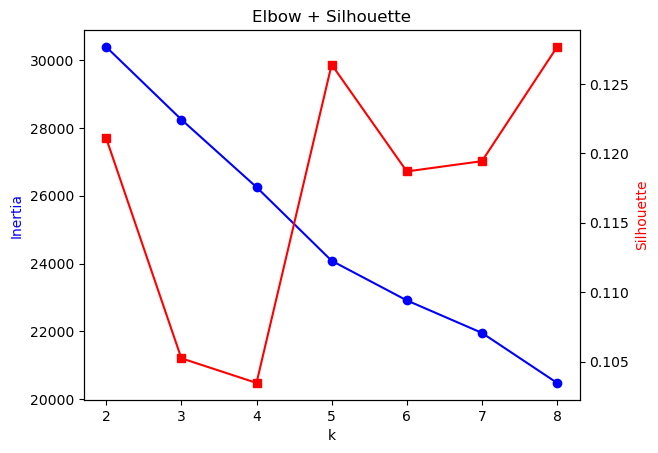

[(2, 30385.224240117906, 0.12108214386710818), (3, 28245.47533150022, 0.10524075389637266), (4, 26253.15541809282, 0.10346650827322737), (5, 24082.76231914105, 0.12638535351175229), (6, 22915.35302763815, 0.11869318384021024), (7, 21956.984329436178, 0.11943252866235017), (8, 20483.15342302166, 0.12765628679544402)]


In [12]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

inertias, silhouettes = [], []
k_range = range(2, 9)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_scaled, labels))

# Plot both on one chart
fig, ax1 = plt.subplots()
ax1.plot(k_range, inertias, marker="o", color="blue")
ax1.set_xlabel("k")
ax1.set_ylabel("Inertia", color="blue")
ax2 = ax1.twinx()
ax2.plot(k_range, silhouettes, marker="s", color="red")
ax2.set_ylabel("Silhouette", color="red")
plt.title("Elbow + Silhouette")
plt.savefig("elbow_silhouette.png")
plt.show()

print(list(zip(k_range, inertias, silhouettes)))

In [18]:
for k, i, s in zip(k_range, inertias, silhouettes):
    print(f"k={k}: inertia={i:.1f}, silhouette={s:.4f}")

k=2: inertia=30385.2, silhouette=0.1211
k=3: inertia=28245.5, silhouette=0.1052
k=4: inertia=26253.2, silhouette=0.1035
k=5: inertia=24082.8, silhouette=0.1264
k=6: inertia=22915.4, silhouette=0.1187
k=7: inertia=21957.0, silhouette=0.1194
k=8: inertia=20483.2, silhouette=0.1277


## Run the final clustering

In [13]:
from sklearn.cluster import AgglomerativeClustering

FINAL_K = 4  # replace with your chosen k

kmeans_final = KMeans(n_clusters=FINAL_K, random_state=42, n_init=10)
clients["cluster_kmeans"] = kmeans_final.fit_predict(X_scaled)

# Validate with a second method
hier = AgglomerativeClustering(n_clusters=FINAL_K, linkage="ward")
clients["cluster_hier"] = hier.fit_predict(X_scaled)

# Profile each cluster — this is the important part
profile = clients.groupby("cluster_kmeans").agg(
    size=("client_id", "count"),
    avg_spend=("total_spend", "mean"),
    avg_unit_price=("avg_unit_price", "mean"),
    avg_age=("age", "mean"),
    avg_satisfaction=("satisfaction_score", "mean"),
    pct_investment=("is_investment", "mean"),
    pct_company=("is_company", "mean"),
    pct_international=("is_international", "mean"),
    pct_loan=("loan_applied_flag", "mean"),
).reset_index()

print(profile)

   cluster_kmeans  size     avg_spend  avg_unit_price    avg_age  \
0               0   529  1.506961e+06   435323.324759  53.483932   
1               1    83  2.135253e+06   336838.320493  63.746988   
2               2   684  1.127991e+06   317305.103122  53.845029   
3               3   704  1.100564e+06   310936.934382  55.098011   

   avg_satisfaction  pct_investment  pct_company  pct_international  pct_loan  
0          3.013233        0.294896     0.058601           0.230624  0.374291  
1          3.578313        0.277108     0.048193           0.096386  0.373494  
2          3.029240        0.314327     0.064327           0.216374  0.361111  
3          2.975852        0.313920     0.034091           0.261364  0.369318  


In [14]:
profile = clients.groupby("cluster_kmeans").agg(
    size=("client_id", "count"),
    avg_spend=("total_spend", "mean"),
    avg_unit_price=("avg_unit_price", "mean"),
    avg_age=("age", "mean"),
    avg_satisfaction=("satisfaction_score", "mean"),
    pct_investment=("is_investment", "mean"),
    pct_company=("is_company", "mean"),
    pct_international=("is_international", "mean"),
    pct_loan=("loan_applied_flag", "mean"),
).reset_index()

profile

,cluster_kmeans,size,avg_spend,avg_unit_price,avg_age,avg_satisfaction,pct_investment,pct_company,pct_international,pct_loan
0,0,529,1.506961e+06,435323.324759,53.483932,3.013233,0.294896,0.058601,0.230624,0.374291
1,1,83,2.135253e+06,336838.320493,63.746988,3.578313,0.277108,0.048193,0.096386,0.373494
2,2,684,1.127991e+06,317305.103122,53.845029,3.029240,0.314327,0.064327,0.216374,0.361111
3,3,704,1.100564e+06,310936.934382,55.098011,2.975852,0.313920,0.034091,0.261364,0.369318


## Name the segments

In [15]:
# Example — replace 0,1,2,3 with YOUR actual cluster numbers from the profile table
segment_names = {
    1: "Luxury / High-Value Buyers",
    0: "Leveraged Growth Investors",
    3: "Core Market Investors",
    2: "Emerging Mid-Market Buyers",
}
clients["segment_label"] = clients["cluster_kmeans"].map(segment_names)

clients.to_csv("clients_segmented.csv", index=False)

In [16]:
print("Saved!")

Saved!


In [17]:
import os
print(os.listdir())

['.aws', '.conda', '.condarc', '.continuum', '.ipynb_checkpoints', '.ipython', '.jupyter', '.matplotlib', '.ssh', '.streamlit', '.vscode', 'a.csv', 'adult.data', 'AI .ipynb', 'anaconda3', 'APIConsumer-kafka.ipynb', 'APIKafka-producer.ipynb', 'app.py', 'AppData', 'Application Data', 'Banking EDA.ipynb', 'Banking.csv', 'banking.ipynb', 'bezdekIris.data', 'Boston.csv', 'cars.csv', 'clients.csv', 'clients_segmented.csv', 'column transformer.ipynb', 'composer.json', 'composer.lock', 'Contacts', 'Cookies', 'covid_toy.csv', 'credit card .csv', 'credit consumer.ipynb', 'credit kafka.ipynb', 'creditcard.csv', 'customer.csv', 'Customer_Behavior.ipynb', 'customer_shopping_behavior.csv', 'da1.csv', 'day (1).csv', 'day.csv', 'Desktop', 'df.csv', 'Documents', 'Downloads', 'elbow_silhouette.png', 'Favorites', 'filename.npy', 'Fruit Prices 2020.csv', 'Grading test.ipynb', 'haberman.csv', 'Housing .ipynb', 'housing.csv', 'indexProcessed.csv', 'Introduction.ipynb', 'iris.data', 'k means clustering.ipynb